<a href="https://colab.research.google.com/github/AntaraFirozParsa/Data-Wrangling-basic-/blob/main/Handling_Missing_Data_(Advanced_Imputation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

from sklearn.experimental import enable_iterative_imputer  # 👈 must come first
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

data = {
    'name':            ['Alice','Bob','Charlie','Diana','Eve','Frank','Grace','Henry','Iris','Jack'],
    'age':             [25, 32, 28, np.nan, 45, 38, 29, np.nan, 52, 34],
    'education_years': [16, 14, 18, 12, 20, 16, 14, 18, np.nan, 16],
    'job_level':       [2, 3, 2, 1, 5, 4, 2, 3, 5, np.nan],
    'income':          [50000, 72000, np.nan, 38000, np.nan, 95000, 52000, np.nan, 120000, 68000],
    'date':            pd.date_range('2024-01-01', periods=10, freq='ME')
}

df = pd.DataFrame(data)
print(df)
print("\nMissing values:\n", df.isnull().sum())

      name   age  education_years  job_level    income       date
0    Alice  25.0             16.0        2.0   50000.0 2024-01-31
1      Bob  32.0             14.0        3.0   72000.0 2024-02-29
2  Charlie  28.0             18.0        2.0       NaN 2024-03-31
3    Diana   NaN             12.0        1.0   38000.0 2024-04-30
4      Eve  45.0             20.0        5.0       NaN 2024-05-31
5    Frank  38.0             16.0        4.0   95000.0 2024-06-30
6    Grace  29.0             14.0        2.0   52000.0 2024-07-31
7    Henry   NaN             18.0        3.0       NaN 2024-08-31
8     Iris  52.0              NaN        5.0  120000.0 2024-09-30
9     Jack  34.0             16.0        NaN   68000.0 2024-10-31

Missing values:
 name               0
age                2
education_years    1
job_level          1
income             3
date               0
dtype: int64


### **Technique 1 — Mean / Median / Mode Imputation**

**What it does:** Replaces missing values with a simple statistical summary of the column.
**When to use**:

Quick baseline before trying advanced methods.

Works well when data is roughly symmetric (mean) or skewed (median)

Mode is for categorical columns

Weakness: Shrinks variance, distorts correlations, ignores relationships with other columns.

**Use Mean when:**
Data is numerical,
Data is normally distributed (symmetric),
No extreme outliers

**Use Median when:**
Data is numerical,
Data is skewed,
There are outliers

Real-world examples:
Income 💰
House prices 🏠
Salary data

👉 These are usually skewed, so median is better

**Use Mode when:**
Data is categorical (text/labels),
Data is discrete

In [5]:
df_simple = df.copy()

# --- Mean imputation ---
mean_income = df_simple['income'].mean()
df_simple['income_mean'] = df_simple['income'].fillna(mean_income)

# --- Median imputation (better for skewed data) ---
median_income = df_simple['income'].median()
df_simple['income_median'] = df_simple['income'].fillna(median_income)

# --- Mode imputation (for categorical) ---
mode_job = df_simple['job_level'].mode()[0].   # mode()-Finds the most frequent value(s) in the column, [0] - Takes the first value from that result
df_simple['job_level'] = df_simple['job_level'].fillna(mode_job)

# --- Using sklearn SimpleImputer ---
imputer = SimpleImputer(strategy='median')   # or 'mean', 'most_frequent', 'constant'
df_simple[['income_sklearn']] = imputer.fit_transform(df_simple[['income']])

print(df_simple[['name', 'income', 'job_level', 'income_mean', 'income_median', 'income_sklearn']])

      name    income  job_level    income_mean  income_median  income_sklearn
0    Alice   50000.0        2.0   50000.000000        50000.0         50000.0
1      Bob   72000.0        3.0   72000.000000        72000.0         72000.0
2  Charlie       NaN        2.0   70714.285714        68000.0         68000.0
3    Diana   38000.0        1.0   38000.000000        38000.0         38000.0
4      Eve       NaN        5.0   70714.285714        68000.0         68000.0
5    Frank   95000.0        4.0   95000.000000        95000.0         95000.0
6    Grace   52000.0        2.0   52000.000000        52000.0         52000.0
7    Henry       NaN        3.0   70714.285714        68000.0         68000.0
8     Iris  120000.0        5.0  120000.000000       120000.0        120000.0
9     Jack   68000.0        2.0   68000.000000        68000.0         68000.0


### **Technique 2 — Forward Fill / Backward Fill (Time Series)**

**What it does:** Propagates the last known value forward (ffill) or the next known value backward (bfill) through the DataFrame.

**When to use:**

Time-series data (stock prices, sensor readings, monthly records)

When the assumption is "value stays the same until we know otherwise"

**Weakness:** Bad for non-sequential data. Can propagate errors if gaps are long.

In [6]:
df_ts = df[['date', 'income']].copy()
print("Before fill:\n", df_ts)

# Forward fill — use previous known value
df_ts['income_ffill'] = df_ts['income'].ffill()

# Backward fill — use next known value
df_ts['income_bfill'] = df_ts['income'].bfill()

# Limit how far to fill (e.g., max 1 step)
df_ts['income_ffill_limit'] = df_ts['income'].ffill(limit=1). # (limit=1) - Only fill 1 step forward, not all

print("\nAfter fill:\n", df_ts)

Before fill:
         date    income
0 2024-01-31   50000.0
1 2024-02-29   72000.0
2 2024-03-31       NaN
3 2024-04-30   38000.0
4 2024-05-31       NaN
5 2024-06-30   95000.0
6 2024-07-31   52000.0
7 2024-08-31       NaN
8 2024-09-30  120000.0
9 2024-10-31   68000.0

After fill:
         date    income  income_ffill  income_bfill  income_ffill_limit
0 2024-01-31   50000.0       50000.0       50000.0             50000.0
1 2024-02-29   72000.0       72000.0       72000.0             72000.0
2 2024-03-31       NaN       72000.0       38000.0             72000.0
3 2024-04-30   38000.0       38000.0       38000.0             38000.0
4 2024-05-31       NaN       38000.0       95000.0             38000.0
5 2024-06-30   95000.0       95000.0       95000.0             95000.0
6 2024-07-31   52000.0       52000.0       52000.0             52000.0
7 2024-08-31       NaN       52000.0      120000.0             52000.0
8 2024-09-30  120000.0      120000.0      120000.0            120000.0
9 2024-10

### **Technique 3 — KNN Imputation**

**What it does:** For each missing value, it finds the K most similar rows (nearest neighbors) based on other columns, then fills with their average.

**When to use:**

When missing values have relationships with multiple other columns

Medium-sized datasets (can be slow on very large ones)

When you want something smarter than mean/median but simpler than MICE

**Weakness:** Sensitive to scale — always scale your data first. Slow on large datasets.

Original Data
     ↓
Scale data
     ↓
Find nearest neighbors
     ↓
Fill missing values
     ↓
Convert back to original values
     ↓
Compare results

In [7]:
from sklearn.preprocessing import StandardScaler

df_knn = df[['age', 'education_years', 'job_level', 'income']].copy()

# Scale first — KNN is distance-based, so scale matters
scaler = StandardScaler()  #StandardScaler():Converts data to same scale
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_knn),
    columns=df_knn.columns
)

# Apply KNN imputer on scaled data
knn_imputer = KNNImputer(n_neighbors=3)
df_knn_imputed_scaled = pd.DataFrame(
    knn_imputer.fit_transform(df_scaled),
    columns=df_knn.columns
)

# Inverse transform to get back original scale
df_knn_result = pd.DataFrame(
    scaler.inverse_transform(df_knn_imputed_scaled),
    columns=df_knn.columns
)

df_knn['income_knn'] = df_knn_result['income'].round(2)
print(df_knn[['income', 'income_knn']])

     income  income_knn
0   50000.0    50000.00
1   72000.0    72000.00
2       NaN    56666.67
3   38000.0    38000.00
4       NaN    94333.33
5   95000.0    95000.00
6   52000.0    52000.00
7       NaN    71000.00
8  120000.0   120000.00
9   68000.0    68000.00


**Technique 4 — Regression Imputation**

**What it does:** Trains a regression model on rows where income is known, using age, education_years, and job_level as features. Then predicts income for missing rows.

**When to use:**

When you know which features predict the missing column well

When you want interpretability — you can see which features matter

Good middle ground between simple and MICE

**Weakness:** Assumes a linear relationship (unless you use a non-linear model). Underestimates variance since predictions are too "perfect."

Split data
   ↓
Train model on complete rows
   ↓
Predict missing values
   ↓
Insert predictions back
   ↓
Keep original where needed

*Faster than KNN for large data

In [8]:
df_reg = df[['age', 'education_years', 'job_level', 'income']].copy()

# Split into rows where income is known vs missing
known = df_reg[df_reg['income'].notna()].dropna()     # complete rows for training, AND no missing values in any column (dropna())
missing = df_reg[df_reg['income'].isna()]              # rows to predict, income is missing

features = ['age', 'education_years', 'job_level']

X_train = known[features]
y_train = known['income']
X_pred  = missing[features].dropna()   # features must be complete for prediction, Because model cannot predict if inputs are missing

# Train a linear regression model
model = LinearRegression()   #Model learns relationship: income = a×age + b×education + c×job_level
model.fit(X_train, y_train)

# Predict missing incomes
predicted = model.predict(X_pred)
print("Predicted incomes:", predicted.round(2))

# Fill back into DataFrame
df_reg.loc[X_pred.index, 'income_regression'] = predicted.round(2) #X_pred.index → ensures values go to correct rows
df_reg['income_regression'] = df_reg['income_regression'].fillna(df_reg['income']) #fill remaining values

print("\nCoefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.2f}")

print(df_reg[['income', 'income_regression']])

Predicted incomes: [ 53000.   119571.43]

Coefficients:
  age: 714.29
  education_years: 428.57
  job_level: 17857.14
     income  income_regression
0   50000.0           50000.00
1   72000.0           72000.00
2       NaN           53000.00
3   38000.0           38000.00
4       NaN          119571.43
5   95000.0           95000.00
6   52000.0           52000.00
7       NaN                NaN
8  120000.0          120000.00
9   68000.0           68000.00


**Technique 5 — MICE (Multiple Imputation by Chained Equations)**

**What it does:** The most powerful technique. It models each column with missing values as a function of all other columns, then iterates through them repeatedly until the imputations converge. This is what IterativeImputer in sklearn implements.

**When to use:**

Multiple columns have missing values simultaneously

When statistical validity matters (research, reporting)

When you want to preserve relationships between variables

**Weakness:** Computationally expensive. Requires careful setup. Harder to explain to non-technical stakeholders.

Initial data
   ↓
Fill rough guesses
   ↓
Train model for each column
   ↓
Predict missing values
   ↓
Repeat multiple times
   ↓
Final refined dataset

In [9]:
from sklearn.experimental import enable_iterative_imputer   # must enable first , IterativeImputer is experimental in scikit-learn
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

df_mice = df[['age', 'education_years', 'job_level', 'income']].copy()

print("Missing before MICE:\n", df_mice.isnull().sum())

# --- Basic MICE (linear estimator, default) ---
mice_imputer = IterativeImputer(
    max_iter=10,        # number of full cycles through columns
    random_state=42,    #For reproducibility
    verbose=0
)
df_mice_result = pd.DataFrame(
    mice_imputer.fit_transform(df_mice),
).round(2).        # fit_transform(): learns relationships, fills missing values

print("\nAfter MICE:\n", df_mice_result)

# --- Advanced: MICE with Random Forest estimator ---
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=50, random_state=42),
    max_iter=10,
    random_state=42
)
df_mice_rf = pd.DataFrame(
    rf_imputer.fit_transform(df_mice),
    columns=df_mice.columns
).round(2)

print("\nAfter MICE + RandomForest:\n", df_mice_rf)
print("\nMissing after MICE:", df_mice_result.isnull().sum().sum())

Missing before MICE:
 age                2
education_years    1
job_level          1
income             3
dtype: int64

After MICE:
      age  education_years  job_level     income
0  25.00            16.00       2.00   50000.00
1  32.00            14.00       3.00   72000.00
2  28.00            18.00       2.00   55496.35
3  22.07            12.00       1.00   38000.00
4  45.00            20.00       5.00  105269.16
5  38.00            16.00       4.00   95000.00
6  29.00            14.00       2.00   52000.00
7  33.86            18.00       3.00   72633.75
8  52.00            19.83       5.00  120000.00
9  34.00            16.00       2.73   68000.00

After MICE + RandomForest:
      age  education_years  job_level    income
0  25.00            16.00       2.00   50000.0
1  32.00            14.00       3.00   72000.0
2  28.00            18.00       2.00   58640.0
3  26.62            12.00       1.00   38000.0
4  45.00            20.00       5.00  103480.0
5  38.00            16.00   

In [10]:
results = pd.DataFrame({
    'name':            df['name'],
    'actual_income':   df['income'],
    'mean':            df['income'].fillna(df['income'].mean()).round(0),
    'median':          df['income'].fillna(df['income'].median()).round(0),
    'knn':             df_knn_result['income'].round(0),
    'regression':      df_reg['income_regression'].round(0),
    'mice':            df_mice_result['income'].round(0),
    'mice_rf':         df_mice_rf['income'].round(0),
})

# Highlight the imputed rows
mask = df['income'].isna()
print("=== Imputed rows comparison ===")
print(results[mask].to_string(index=False))

=== Imputed rows comparison ===
   name  actual_income    mean  median     knn  regression     mice  mice_rf
Charlie            NaN 70714.0 68000.0 56667.0     53000.0  55496.0  58640.0
    Eve            NaN 70714.0 68000.0 94333.0    119571.0 105269.0 103480.0
  Henry            NaN 70714.0 68000.0 71000.0         NaN  72634.0  72940.0


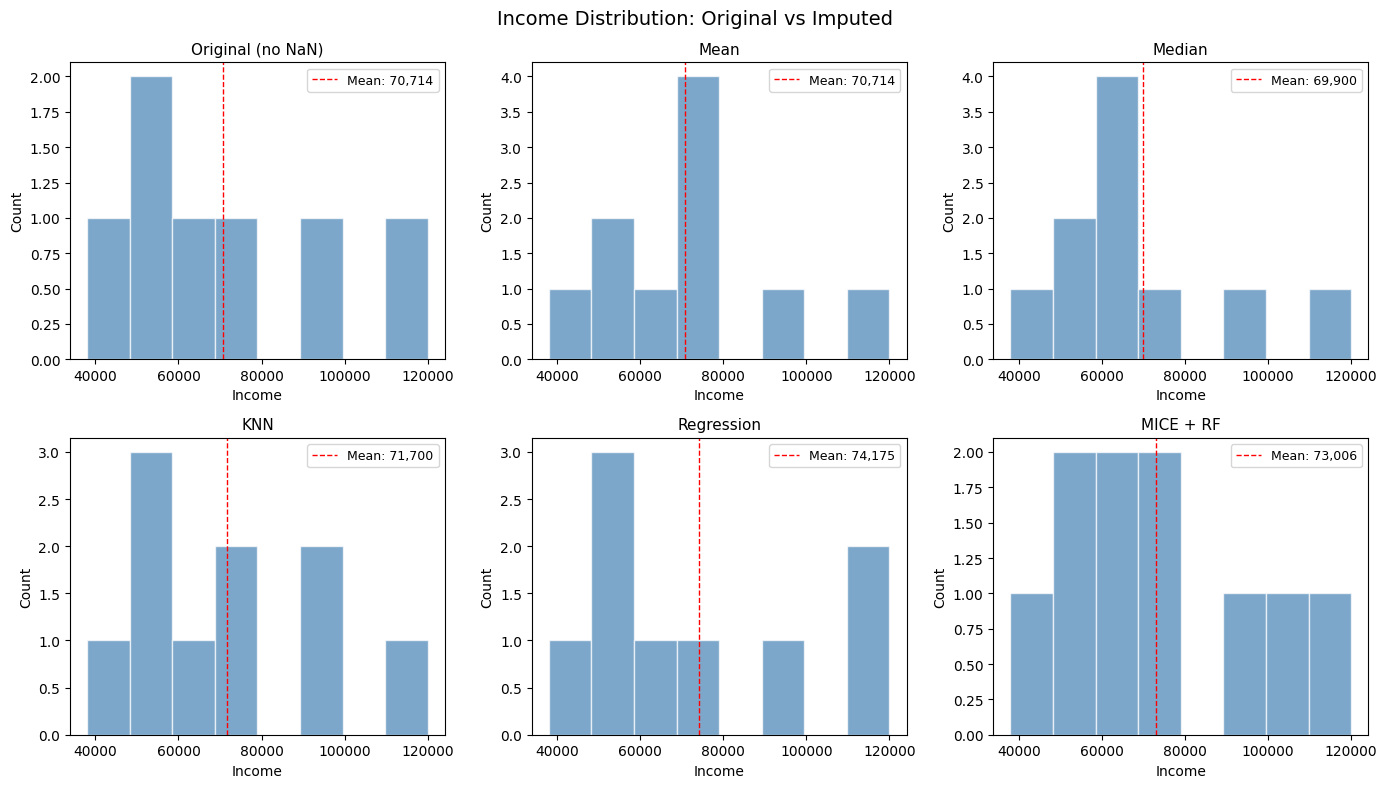

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Income Distribution: Original vs Imputed', fontsize=14)

methods = {
    'Original (no NaN)': df['income'].dropna(),
    'Mean':       results['mean'],
    'Median':     results['median'],
    'KNN':        results['knn'],
    'Regression': results['regression'],
    'MICE + RF':  results['mice_rf'],
}

for ax, (title, data) in zip(axes.flat, methods.items()):
    ax.hist(data, bins=8, color='steelblue', alpha=0.7, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Income')
    ax.set_ylabel('Count')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {data.mean():,.0f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()